# 🔋 Predicting Battery Degradation Through Cycling Data 🔋

**Spring 2026 Data Science Project — CMSC 320**
**Lixin Nie**

## Contributions

This is a solo project; all sections were completed by Lixin Nie.

- **A: Project idea** — selected the CALCE cycling data for battery analysis.
- **B: Dataset curation and preprocessing** — downloaded and combined 35 raw CALCE cycling files, performed necessary cleaning and preprocessing. 
- **C: Data exploration and summary statistics** — computed Pearson and Spearman correlations, fit a linear regression for the degradation trend, ran a two-sample t-test comparing early- and late-life cycles, and used a Mann–Whitney U test to verify charge/discharge voltage distributions differ.
- **D: ML algorithm design/development** — engineered per-cycle behavioral features from the raw time-series.
- **E: ML algorithm training and test data analysis** — trained four regression models, evaluated on a chronological hold-out split and via 5-fold cross-validation, computed feature importances.
- **F: Visualization, result analysis, conclusion** — produced all visualizations and drawn final conclusion. 
- **G: Final tutorial report creation** — final revision and submission. 

## Introduction

Lithium-ion batteries power nearly every modern application that needs portable energy: consumer electronics, electric vehicles, grid storage, medical devices. The fundamental challenge with these batteries is that they degrade over time — capacity fades, internal resistance grows, and at some point the cell can no longer support the device's specification. Understanding *how* and *how fast* this degradation happens is critical for warranty modeling, second-life applications, and recycling decisions.

This tutorial walks through a full data-science pipeline applied to publicly available battery cycling data from the Center for Advanced Life Cycle Engineering ([CALCE](https://calce.umd.edu/battery-data)) at the University of Maryland. We start from raw experimental files, build a clean per-cycle dataset, explore it with statistical tests, and finally train and evaluate machine-learning models that predict capacity from per-cycle behavioral features.

Specifically, we ask three questions:

1. **Does battery capacity decline systematically with cycle count, or is the decline noisy and non-monotonic?**
2. **Is there a statistically significant capacity gap between early-life and late-life cycles, and how does the variability of capacity change as the battery ages?**
3. **Can per-cycle behavioral features (charge duration, time spent in the constant-voltage phase, voltage plateau time) predict capacity better than cycle index alone?**

By the end of the notebook, the reader should walk away with both a concrete answer to each question and a reusable template for analyzing other cycling datasets.


## Data Pre-Processing

The data-collection stage of the data-science lifecycle involves gathering relevant data that will help answer our research questions. For this project, we use battery cycling data provided by the **Center for Advanced Life Cycle Engineering (CALCE)** at the University of Maryland, available at [https://calce.umd.edu/battery-data](https://calce.umd.edu/battery-data). CALCE provides open-access experimental data on lithium-ion battery performance, including continuous full and partial cycling, storage conditions, dynamic driving profiles, open-circuit voltage measurements, and impedance data. Battery form factors include cylindrical, pouch, and prismatic cells.

The dataset includes high-resolution measurements of voltage, current, capacity, temperature, and cycle count. These variables let us track how battery performance evolves over time and under repeated usage, which is exactly what we need for analyzing degradation patterns. Because the data is collected and shared by a reputable research institution, it is reliable and suitable for scientific analysis. For this tutorial we focus on the CS2_8 cell, which provides ~100 charge–discharge cycles split across 35 raw files.

We will use Python modules **numpy**, **pandas**, **matplotlib**, **scipy**, and **scikit-learn** to load, process, analyze, visualize, and model the data.


In [1]:
# Importing the necessary packages
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


The dataset is stored in `.txt` files. Unlike standard CSVs, this dataset uses a tab (`\t`) as the delimiter, so we explicitly specify the separator when loading the data with pandas.

We first downloaded the CS2 dataset from the CALCE website and copied the entire directory into our working environment:

<pre> (.venv) lixinnie@LIXINLAPTOP:~/CMSC320-Battery-Degradation-Prediction/CS2_8$ ls
CS2_8_1_19_10.txt  CS2_8_2_02_10.txt  CS2_8_4_5_10.txt   CS2_8_6_8_10.txt   CS2_8_7_9_10.txt   CS2_8_8_30_10.txt
CS2_8_1_20_10.txt  CS2_8_2_04_10.txt  CS2_8_4_8_10.txt   CS2_8_7_12_10.txt  CS2_8_8_10_10.txt  CS2_8_8_4_10.txt
CS2_8_1_26_10.txt  CS2_8_2_22_10.txt  CS2_8_5_11_10.txt  CS2_8_7_19_10.txt  CS2_8_8_12_10.txt  CS2_8_8_6_10.txt
CS2_8_1_27_10.txt  CS2_8_2_24_10.txt  CS2_8_5_14_10.txt  CS2_8_7_22_10.txt  CS2_8_8_13_10.txt  CS2_8_9_21_10.txt
CS2_8_1_28_10.txt  CS2_8_3_5_10.txt   CS2_8_6_1_10.txt   CS2_8_7_27_10.txt  CS2_8_8_19_10.txt  CS2_8_9_7_10.txt
CS2_8_1_29_10.txt  CS2_8_4_26_10.txt  CS2_8_6_7_10.txt   CS2_8_7_8_10.txt   CS2_8_8_23_10.txt </pre>

The full series contains 35 files, so we begin by previewing a single file to get a rough idea of it's shape, then combine all files into a single DataFrame.

In [2]:
# We need the additional argument `sep="\t"` since the separator is not a comma.
df = pd.read_csv("./CS2_8/CS2_8_1_19_10.txt", sep="\t")

print("Shape of dataframe (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head()


Shape of dataframe (rows, columns): (3268, 30)

Column names:
['Time', 'Status code', 'Status category', 'Status color', 'Pgm code', 'Pgm step', 'Pgm para', 'Pgm cycle', 'mV', 'mA', 'Temperature', 'Duration', 'Charge count', 'Discharge count', 'Capacity', 'Analog input 1', 'Analog input 2', 'Analog input 3', 'Analog input 4', 'Digital input 1', 'Digital input 2', 'Digital input 3', 'Digital input 4', 'Digital output 1', 'Digital output 2', 'Digital output 3', 'Digital output 4', 'Analog output 1', 'Analog output 2', 'Unnamed: 29']


,Time,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,mV,mA,...,Digital input 2,Digital input 3,Digital input 4,Digital output 1,Digital output 2,Digital output 3,Digital output 4,Analog output 1,Analog output 2,Unnamed: 29
0,0.000000,8,3,3,0,1,2,2,4005,552,...,0,0,0,0,0,0,0,0,0,NaN
1,0.750233,8,3,3,0,1,2,2,4030,550,...,0,0,0,0,0,0,0,0,0,NaN
2,1.745283,8,3,3,0,1,2,2,4042,548,...,0,0,0,0,0,0,0,0,0,NaN
3,2.761917,8,3,3,0,1,2,2,4047,549,...,0,0,0,0,0,0,0,0,0,NaN
4,3.758400,8,3,3,0,1,2,2,4051,550,...,0,0,0,0,0,0,0,0,0,NaN


Now that we have a rough idea of what a single file looks like, let's combine them all into one DataFrame.

In [3]:
files = sorted(glob.glob('./CS2_8/CS2_8_*.txt'))
print(f"Found {len(files)} files")

dfs = []
for f in files:
    temp = pd.read_csv(f, sep='\t')
    temp = temp.drop(columns=temp.columns[temp.isnull().all()])  # drop NaN columns before concat
    temp.columns = temp.columns.str.strip()
    temp['source_file'] = f  # keep track of where each row came from
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {df.shape}")
df.head()


Found 35 files
Combined shape: (359794, 30)


,Time,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,mV,mA,...,Digital input 2,Digital input 3,Digital input 4,Digital output 1,Digital output 2,Digital output 3,Digital output 4,Analog output 1,Analog output 2,source_file
0,0.000000,8,3,3,0,1,2,2,4005,552,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
1,0.750233,8,3,3,0,1,2,2,4030,550,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
2,1.745283,8,3,3,0,1,2,2,4042,548,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
3,2.761917,8,3,3,0,1,2,2,4047,549,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt
4,3.758400,8,3,3,0,1,2,2,4051,550,...,0,0,0,0,0,0,0,0,0,./CS2_8/CS2_8_1_19_10.txt


Proper data cleaning is a critical step in the pipeline. Even when datasets appear structured, unnecessary columns, inconsistent naming, and unclear units can hinder analysis. For this DataFrame, it would be wise to drop all Digital Input, Digital Output, Analog Input, and Analog Output columns that are entirely zero across every row in every file. These channels recorded no data during the experiment, so they carry no information and would only add noise and memory overhead.

In [4]:
# There are quite a few all-zero columns; we identify them with a loop.
io_cols = [c for c in df.columns if any(
    c.startswith(prefix) for prefix in
    ['Analog input', 'Analog output', 'Digital input', 'Digital output']
)]

zero_io_cols = [c for c in io_cols if (df[c] == 0).all()]
df = df.drop(columns=zero_io_cols)

print("Shape of dataframe (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head()


Shape of dataframe (rows, columns): (359794, 16)

Column names:
['Time', 'Status code', 'Status category', 'Status color', 'Pgm code', 'Pgm step', 'Pgm para', 'Pgm cycle', 'mV', 'mA', 'Temperature', 'Duration', 'Charge count', 'Discharge count', 'Capacity', 'source_file']


,Time,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,mV,mA,Temperature,Duration,Charge count,Discharge count,Capacity,source_file
0,0.000000,8,3,3,0,1,2,2,4005,552,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt
1,0.750233,8,3,3,0,1,2,2,4030,550,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt
2,1.745283,8,3,3,0,1,2,2,4042,548,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt
3,2.761917,8,3,3,0,1,2,2,4047,549,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt
4,3.758400,8,3,3,0,1,2,2,4051,550,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt


We now convert mV→V and mA→A so calculations match standard SI units; otherwise quantities like capacity and energy would be off by 1000× and incompatible with formulas, plots, and library defaults. We also standardize time units: in the raw file, `Time` is in minutes while `Duration` is in seconds. Converting both to seconds avoids errors in cycle analysis and makes future steps much easier. 

In [5]:
# Converting time to seconds
df['Time'] = df['Time'] * 60

df = df.rename(columns={
    'Time':     'Time_s',
    'Duration': 'Duration_s'
})

# Scale electrical units
df['Voltage_V'] = df['mV'] / 1000
df['Current_A'] = df['mA'] / 1000
df = df.drop(columns=['mV', 'mA'])

df.head()


,Time_s,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,Temperature,Duration_s,Charge count,Discharge count,Capacity,source_file,Voltage_V,Current_A
0,0.00000,8,3,3,0,1,2,2,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.005,0.552
1,45.01398,8,3,3,0,1,2,2,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.030,0.550
2,104.71698,8,3,3,0,1,2,2,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.042,0.548
3,165.71502,8,3,3,0,1,2,2,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.047,0.549
4,225.50400,8,3,3,0,1,2,2,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.051,0.550


We decode `phase` from the sign of `Current_A` instead of relying on opaque status codes: positive current = charging, negative = discharging, zero = rest. This makes plots and downstream analysis immediately interpretable.

In [6]:
# Inspect unique values of Status category and how they relate to current sign
print("Status category unique values:", df['Status category'].unique())

current_sign = df['Current_A'].apply(
    lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero')
)
print(pd.crosstab(df['Status category'], current_sign))


Status category unique values: [ 3  6 15  4  0 10  2 11]
Current_A        negative  positive  zero
Status category                          
0                       0         2   165
2                       0         0     2
3                       3    205315  4768
4                       0      1107    10
6                  147115         9     0
10                      0         0     6
11                      0         0     5
15                      0      1258    29


From the table above we can infer that status 3 corresponds to charging and status 6 to discharging. Codes such as 0, 4, and 15 are ambiguous and do not clearly indicate the battery's state. Rather than relying on these unclear codes, we derive a phase column directly from the sign of `Current_A`.

In [7]:
def label_phase(current):
    if current > 0:
        return 'charge'
    elif current < 0:
        return 'discharge'
    else:
        return 'rest'

df['phase'] = df['Current_A'].apply(label_phase)
print(df['phase'].value_counts())
df.head()


phase
charge       207691
discharge    147118
rest           4985
Name: count, dtype: int64


,Time_s,Status code,Status category,Status color,Pgm code,Pgm step,Pgm para,Pgm cycle,Temperature,Duration_s,Charge count,Discharge count,Capacity,source_file,Voltage_V,Current_A,phase
0,0.00000,8,3,3,0,1,2,2,19,2,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.005,0.552,charge
1,45.01398,8,3,3,0,1,2,2,20,47,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.030,0.550,charge
2,104.71698,8,3,3,0,1,2,2,19,107,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.042,0.548,charge
3,165.71502,8,3,3,0,1,2,2,20,168,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.047,0.549,charge
4,225.50400,8,3,3,0,1,2,2,20,228,1,0,0,./CS2_8/CS2_8_1_19_10.txt,4.051,0.550,charge


When a battery cycles through charge and discharge, the `Capacity` column accumulates continuously *within* each phase — it is not a single snapshot but a running counter that grows row by row and resets at phase boundaries. To determine the total capacity delivered in a given discharge cycle we take the maximum value reached before the counter resets, which represents the full capacity for that cycle. This lets us condense the time-series into a single meaningful value per cycle, making it easy to track performance over time and analyze degradation. We now build a summary table that captures this relationship.

In [8]:
# Inspect Pgm cycle and how Capacity behaves within it
print("Pgm cycle unique values:", sorted(df['Pgm cycle'].unique()))

# Look at how Capacity behaves within a single Pgm cycle
sample_cycle = df[df['Pgm cycle'] == 1]
print(f"\nPgm cycle == 1 row count: {len(sample_cycle)}")
sample_cycle[['Time_s', 'Pgm cycle', 'phase', 'Current_A', 'Capacity']].head()


Pgm cycle unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(5)]

Pgm cycle == 1 row count: 147118


,Time_s,Pgm cycle,phase,Current_A,Capacity
149,8904.12498,1,discharge,-0.287,0
150,8926.06998,1,discharge,-0.549,0
151,8986.54998,1,discharge,-0.550,1
152,9045.56202,1,discharge,-0.549,1
153,9105.95502,1,discharge,-0.549,2


`Pgm cycle` has only four distinct values (0, 1, 2, 5), so it is *not* tracking individual cycles — it is tracking program steps in the experiment schedule. The actual cycle counter we want is `Discharge count`, which increments once per full discharge. Within a single value of `Pgm cycle == 1`, `Capacity` resets to 0 many times, confirming that we cannot use `Pgm cycle` as the grouping key. We will group by `Discharge count` instead.

In [9]:
# Verify Discharge count is the right grouping variable
print("Max Discharge count:", df['Discharge count'].max())

(df[df['phase'] == 'discharge'][['Discharge count', 'Capacity']]
   .groupby('Discharge count')
   .agg(['min', 'max', 'count'])
   .head(10))


Max Discharge count: 101


Capacity           
                     min  max count
Discharge count                    
1                      0  100  3965
2                      0  101  4134
3                      0  100  4412
4                      0  100  3888
5                      0  100  3565
6                      0  100  3501
7                      0  100  3238
8                      0   99  3235
9                      0   99  3230
10                     0   99  2950

Grouping by `Discharge count` cleanly separates each discharge into its own block and shows the expected pattern: capacity starts at zero and reaches a peak that decreases over later cycles. We now build a summary table of peak discharge capacity per cycle.

In [10]:
df_discharge = df[df['phase'] == 'discharge']

df_cycles = (
    df_discharge
    .groupby('Discharge count')['Capacity']
    .max()
    .reset_index()
    .rename(columns={
        'Discharge count': 'cycle_number',
        'Capacity':        'peak_capacity'
    })
)

# Drop cycle 0 (no actual discharge data yet)
df_cycles = df_cycles[df_cycles['cycle_number'] > 0].reset_index(drop=True)
df_cycles


,cycle_number,peak_capacity
0,1,100
1,2,101
2,3,100
3,4,100
4,5,100
...,...,...
96,97,94
97,98,94
98,99,94
99,100,94


Before modeling battery degradation we verify that the cycle summary table contains only physically valid capacity readings. Outliers can come from real experimental anomalies (interrupted or partial cycles) or from data artifacts introduced by file boundaries when we merged the cycle files. 

We use a physical-validity threshold to remove these: any cycle with peak capacity above the nominal 101 mAh is flagged as a data artifact. This single rule is sufficient because the only anomalous value (108 mAh) clearly exceeds nominal capacity by a wide margin and would distort the degradation curve if left in.

In [11]:
# General capacity statistics
print(df_cycles['peak_capacity'].describe().round(3))

# Anything above 101 mAh exceeds nominal capacity and is a data artifact
df_cycles_cleaned = df_cycles[df_cycles['peak_capacity'] <= 101].copy().reset_index(drop=True)

print(f"\nDropped {len(df_cycles) - len(df_cycles_cleaned)} anomalous cycle(s)")
print(f"Capacity fade: {df_cycles_cleaned['peak_capacity'].iloc[0]} → "
      f"{df_cycles_cleaned['peak_capacity'].iloc[-1]} mAh")

df_cycles = df_cycles_cleaned


count    101.000
mean      95.505
std        2.352
min       92.000
25%       94.000
50%       95.000
75%       96.000
max      108.000
Name: peak_capacity, dtype: float64

Dropped 1 anomalous cycle(s)
Capacity fade: 100 → 93 mAh


## Exploratory Overview and Data Analysis

Now that the data is cleaned and structured, we begin the exploratory phase. Our cycle summary table captures the relationship between cycle number and peak discharge capacity, so we start with a simple line plot to visualize that relationship before applying any statistical tests.

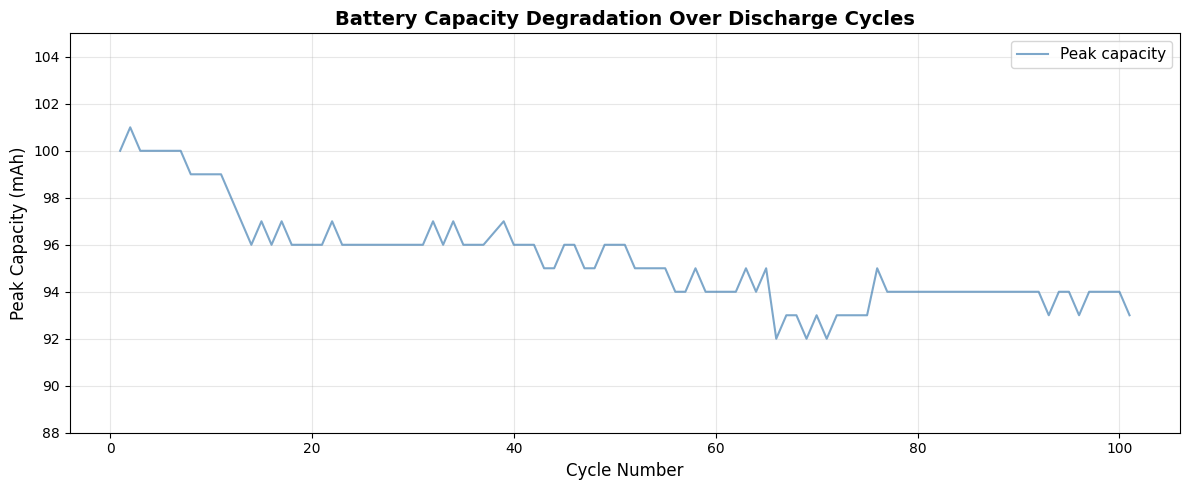

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_cycles['cycle_number'], df_cycles['peak_capacity'],
        color='steelblue', linewidth=1.5, alpha=0.7, label='Peak capacity')

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Battery Capacity Degradation Over Discharge Cycles', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(88, 105)

plt.tight_layout()
plt.show()


The line plot clearly suggests that capacity declines over cycles, but a visual trend is not by itself evidence of a systematic relationship. To formally test whether capacity decreases consistently across all cycles, we compute both the **Pearson** and **Spearman** correlations between cycle number and peak discharge capacity. Pearson captures linear relationships, while Spearman detects any monotonic trend — together they provide a robust view of capacity decline that does not depend on the relationship being strictly linear.

We also fit a **linear regression** model to quantify the rate of capacity fade in mAh per cycle and test whether the slope differs from zero. A statistically significant negative slope would indicate that capacity loss is systematic rather than random variation.

We formalize the regression test using the following hypotheses:

$$
H_0: \beta = 0
$$

$$
H_1: \beta \neq 0
$$


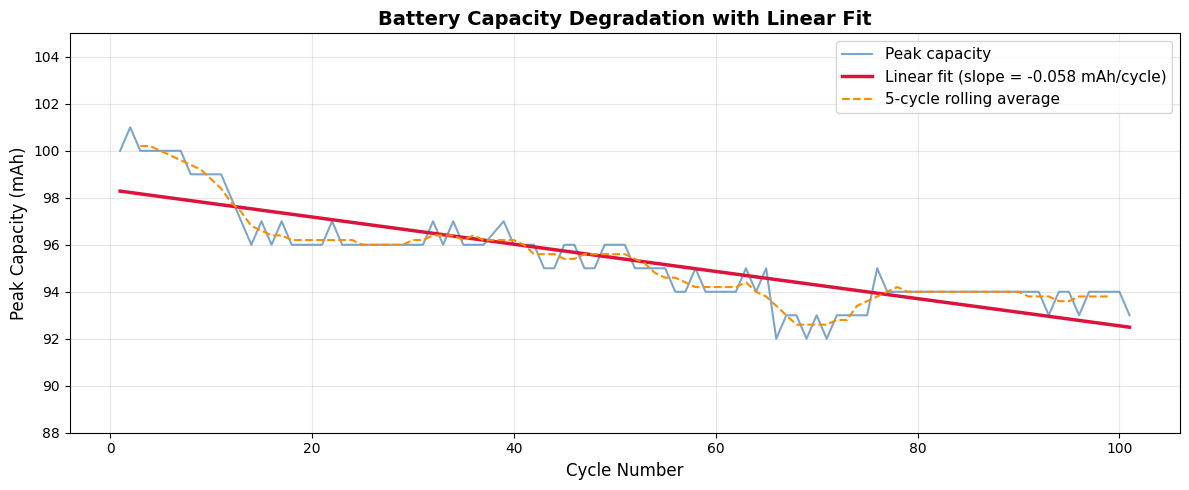

Pearson  r = -0.8525,  p = 2.31e-29
Spearman r = -0.8867,  p = 1.33e-34

Slope:     -0.0579 mAh/cycle
Intercept: 98.3417
R²:        0.7268
p-value:   2.31e-29


In [13]:
# Statistical analysis
pearson_r,  pearson_p  = stats.pearsonr( df_cycles['cycle_number'], df_cycles['peak_capacity'])
spearman_r, spearman_p = stats.spearmanr(df_cycles['cycle_number'], df_cycles['peak_capacity'])

slope, intercept, r, p, se = stats.linregress(
    df_cycles['cycle_number'],
    df_cycles['peak_capacity']
)

x = df_cycles['cycle_number']
y_fit = slope * x + intercept
rolling = df_cycles['peak_capacity'].rolling(window=5, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_cycles['cycle_number'], df_cycles['peak_capacity'],
        color='steelblue', linewidth=1.5, alpha=0.7, label='Peak capacity')
ax.plot(x, y_fit,
        color='crimson', linewidth=2.5,
        label=f'Linear fit (slope = {slope:.3f} mAh/cycle)')
ax.plot(x, rolling,
        color='darkorange', linewidth=1.5, linestyle='--',
        label='5-cycle rolling average')

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Battery Capacity Degradation with Linear Fit', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(88, 105)

plt.tight_layout()
plt.show()

print(f"Pearson  r = {pearson_r:.4f},  p = {pearson_p:.2e}")
print(f"Spearman r = {spearman_r:.4f},  p = {spearman_p:.2e}")
print(f"\nSlope:     {slope:.4f} mAh/cycle")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r**2:.4f}")
print(f"p-value:   {p:.2e}")


To visualize the Spearman rank correlation directly, we plot the **rank** of each cycle's position against the **rank** of its peak capacity. Unlike the linear-regression plot above, this representation makes no assumption about the functional form of the relationship — it captures only the ordinal structure. A perfect monotonic decline would place every point exactly on the diagonal reference line. Deviations from the diagonal reveal cycles where capacity did not follow strict rank order (e.g., transient recoveries or measurement noise), giving a clearer picture of how consistently the degradation trend holds.

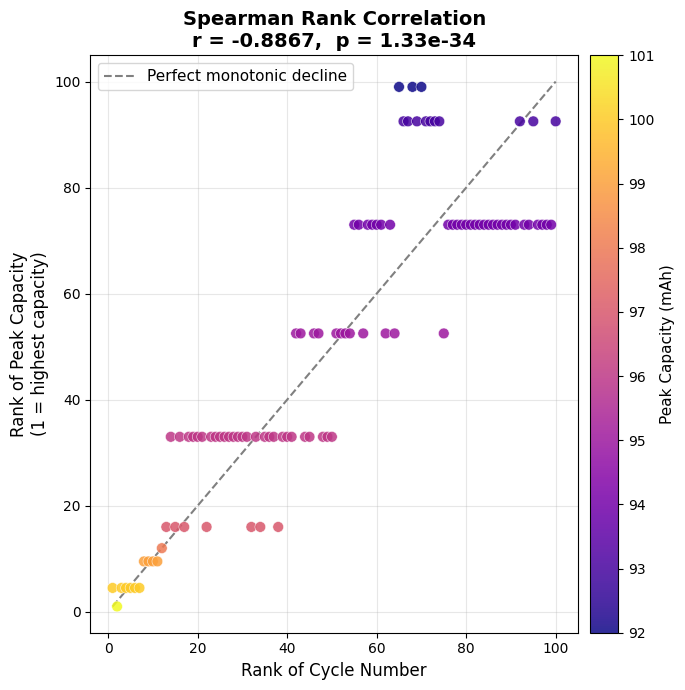

In [14]:
rank_cycle    = df_cycles['cycle_number'].rank()
rank_capacity = df_cycles['peak_capacity'].rank(ascending=False)  # high capacity = low rank

fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(rank_cycle, rank_capacity,
                c=df_cycles['peak_capacity'], cmap='plasma',
                s=60, alpha=0.85, zorder=3, edgecolors='white', linewidths=0.4)

diag = [1, len(df_cycles)]
ax.plot(diag, diag, color='gray', linewidth=1.5, linestyle='--',
        label='Perfect monotonic decline', zorder=2)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Peak Capacity (mAh)', fontsize=11)

ax.set_xlabel('Rank of Cycle Number', fontsize=12)
ax.set_ylabel('Rank of Peak Capacity\n(1 = highest capacity)', fontsize=12)
ax.set_title(f'Spearman Rank Correlation\n'
             f'r = {spearman_r:.4f},  p = {spearman_p:.2e}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The linear regression yields a slope of −0.058 mAh/cycle with a p-value of 2.31 × 10⁻²⁹, which is astronomically smaller than the 0.05 significance threshold. We therefore reject the null hypothesis and conclude that battery capacity does systematically decline with each discharge cycle. This result is further supported by both the Pearson (r = −0.85, p = 2.31 × 10⁻²⁹) and Spearman (r = −0.89, p = 1.33 × 10⁻³⁴) correlation tests, which confirms a strong monotonic negative relationship between cycle number and capacity. The Spearman rank visualization makes this concrete: the cloud of points hugs the diagonal relatively close.

Having established that capacity declines systematically over cycles, we next test whether the difference between **early-life** and **late-life** cycles is statistically significant. We split the data into two groups: the first 20 cycles, representing the battery's healthy state, and the last 20 cycles (cycles 80–100), representing its degraded state. We then apply an independent two-sample t-test with the following hypotheses:

$$
H_0: \mu_{\text{early}} = \mu_{\text{late}}
$$

$$
H_1: \mu_{\text{early}} > \mu_{\text{late}}
$$

A statistically significant result indicates that the observed decline reflects real degradation rather than random variation.

Early 20 — mean: 98.300, std: 1.750, n: 20
Late 20  — mean: 93.864, std: 0.351, n: 22

t-statistic: 11.6477
p-value:     9.94e-15


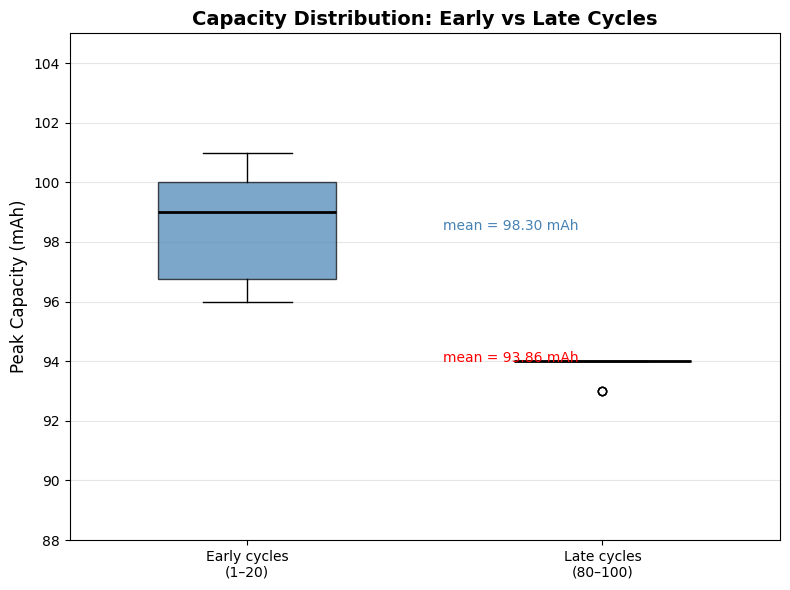

In [15]:
# Split: first 20 cycles as early, last 20 as late
early = df_cycles[df_cycles['cycle_number'] <= 20]['peak_capacity']
late  = df_cycles[df_cycles['cycle_number'] >= 80]['peak_capacity']

print(f"Early 20 — mean: {early.mean():.3f}, std: {early.std():.3f}, n: {len(early)}")
print(f"Late 20  — mean: {late.mean():.3f}, std: {late.std():.3f}, n: {len(late)}")

# One-sided two-sample t-test
t_stat, p_val = stats.ttest_ind(early, late, alternative='greater')
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.2e}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [early, late],
    tick_labels=['Early cycles\n(1–20)', 'Late cycles\n(80–100)'],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('tomato');    bp['boxes'][1].set_alpha(0.7)

ax.annotate(f'mean = {early.mean():.2f} mAh',
            xy=(1.55, early.mean() + 0.1), fontsize=10, color='steelblue')
ax.annotate(f'mean = {late.mean():.2f} mAh',
            xy=(1.55, late.mean() + 0.1),  fontsize=10, color='red')

ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Capacity Distribution: Early vs Late Cycles', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(88, 105)

plt.tight_layout()
plt.show()


The two-sample t-test produces t = 11.65 and p = 9.94 × 10⁻¹⁵, well below 0.05, so we reject the null hypothesis and conclude that capacity has significantly decreased over time. Early cycles (1–20) have a mean capacity of 98.30 mAh (SD = 1.75), while late cycles (80–100) average 93.86 mAh (SD = 0.35). The lower variability in later cycles is itself an interesting finding: the battery does not just get weaker, it also stabilizes at its degraded capacity, with cycle-to-cycle behavior becoming more reproducible as the cell ages. Overall, the 4.44 mAh drop (~4.5%) reflects a meaningful loss in usable capacity.

To better understand the dataset, we also test whether voltage behaves differently during charge and discharge. Physically, this is expected: voltage rises toward ~4.2 V during charging and falls toward ~3.0 V during discharging. We verify this with the **Mann–Whitney U test**, a non-parametric test that compares two distributions without assuming normality.

We define the hypotheses as:

$$
H_0: \text{Charge and discharge voltages come from the same distribution}
$$

$$
H_1: \text{Charge and discharge voltages come from different distributions}
$$

If we reject $H_0$, charge and discharge are truly distinct electrochemical states. This confirms that `phase` is a meaningful feature for any modeling we do downstream.

Charge    — mean: 4.0688 V, std: 0.2056 V, n: 207691
Discharge — mean: 3.6446 V, std: 0.2054 V, n: 147118

Mann-Whitney U statistic: 28739908376.00
p-value:                  0.00e+00


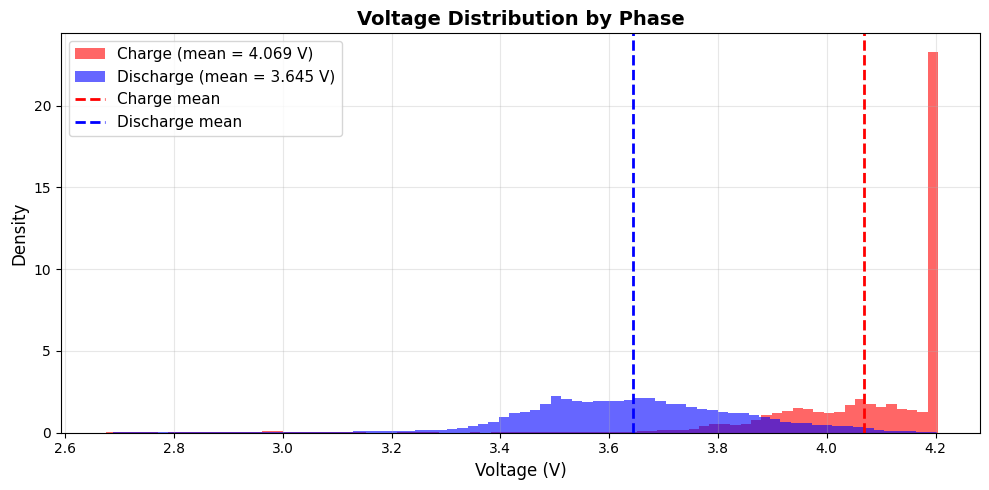

In [16]:
# Keep only charge and discharge phases (drop rest)
charge_v    = df[df['phase'] == 'charge']['Voltage_V']
discharge_v = df[df['phase'] == 'discharge']['Voltage_V']

print(f"Charge    — mean: {charge_v.mean():.4f} V, std: {charge_v.std():.4f} V, n: {len(charge_v)}")
print(f"Discharge — mean: {discharge_v.mean():.4f} V, std: {discharge_v.std():.4f} V, n: {len(discharge_v)}")

u_stat, p_val = stats.mannwhitneyu(charge_v, discharge_v, alternative='two-sided')
print(f"\nMann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value:                  {p_val:.2e}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(charge_v,    bins=80, alpha=0.6, color='red',
        density=True, label=f'Charge (mean = {charge_v.mean():.3f} V)')
ax.hist(discharge_v, bins=80, alpha=0.6, color='blue',
        density=True, label=f'Discharge (mean = {discharge_v.mean():.3f} V)')

ax.axvline(charge_v.mean(),    color='red',  linestyle='--', linewidth=2, label='Charge mean')
ax.axvline(discharge_v.mean(), color='blue', linestyle='--', linewidth=2, label='Discharge mean')

ax.set_xlabel('Voltage (V)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Voltage Distribution by Phase', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The Mann–Whitney U test gives a U-statistic of 2.87 × 10¹⁰ and a p-value so small that floating-point representation rounds it to zero — well below 0.05. We reject the null hypothesis and conclude that charge and discharge voltages come from different distributions. On average, charge voltage is 4.069 V and discharge voltage is 3.645 V, a 0.424 V gap. Both phases have similar internal spreads (~0.206 V), meaning each phase is consistent within itself but clearly separate from the other. This makes physical sense: voltage rises toward 4.2 V during charging and falls toward 3.0 V during discharging. For modeling, it confirms that `phase` is an important feature that captures distinct battery states and should be incorporated into any further analysis.

### Summary of Exploratory Findings

Through statistical testing we have established three findings about this battery dataset:

1. **Capacity declines systematically with cycles.** Linear regression shows a fade rate of about **0.058 mAh per cycle**, with cycle number alone explaining 72.7% of the variance (R² = 0.727, p = 2.31 × 10⁻²⁹). Both Pearson (r = −0.85) and Spearman (r = −0.89) confirm the trend is monotonic.

2. **Early- and late-life capacities are significantly different.** A two-sample t-test shows the first 20 cycles average **98.30 mAh** and the last 20 cycles average **93.86 mAh** (t = 11.65, p = 9.94 × 10⁻¹⁵), a 4.5% drop. Late cycles also show much lower variability (SD = 0.35 vs 1.75), indicating the battery stabilizes at its degraded capacity.

3. **Charge and discharge are distinct voltage regimes.** The Mann–Whitney U test rejects the hypothesis that charge and discharge voltages come from the same distribution (p ≈ 0). Mean charge voltage is 4.069 V and mean discharge voltage is 3.645 V, a 0.424 V gap that reflects real electrochemical separation.

These findings tell us that degradation happens. The next section asks whether we can predict it from per-cycle behavior.

## Primary Analysis: Predicting Capacity from Cycle Behavior

Our exploratory analysis confirmed that battery capacity declines systematically with cycle number, but cycle number alone is a coarse predictor — it tells us *when* a cycle happened, not *how* the battery actually behaved during it. Two batteries at the same cycle number could be in very different health states depending on usage history, temperature, and load profile.

To build a more informative model, we will extract **per-cycle behavioral features** from the raw time-series data and use them to predict peak discharge capacity. The intuition is that the way a battery charges and discharges changes measurably as it degrades: a healthy cell holds voltage longer, spends more time topping off in the constant-voltage phase, and delivers more before the cutoff. By converting the time-series into a compact per-cycle feature table, we can train a regression model that learns these behavioral signatures.

### Step 1: Verifying Charge–Discharge Alignment

Before aggregating features we need to understand how charge and discharge phases are indexed in the dataset. The raw data has two counters — `Charge count` and `Discharge count` — and it is not immediately obvious whether they pair one-to-one. If charge cycle *N* maps cleanly to discharge cycle *N*, we can join them directly. If not, we need a different grouping strategy.

In [17]:
pairing = (
    df[df['phase'].isin(['charge', 'discharge'])]
    .groupby(['Discharge count', 'phase'])['Charge count']
    .agg(['min', 'max', 'nunique'])
)
print(pairing.head(20))
print("\nMax Charge count:", df['Charge count'].max())
print("Max Discharge count:", df['Discharge count'].max())


                           min  max  nunique
Discharge count phase                       
0               charge       1    2        2
1               charge       2    4        3
                discharge    1    2        2
2               charge       4    6        3
                discharge    3    4        2
3               charge       6    8        3
                discharge    5    6        2
4               charge       8   10        3
                discharge    7    8        2
5               charge      10   12        3
                discharge    9   10        2
6               charge      12   14        3
                discharge   11   12        2
7               charge      14   16        3
                discharge   13   14        2
8               charge      16   18        3
                discharge   15   16        2
9               charge      18   20        3
                discharge   17   18        2
10              charge      20   22        3

Max Charg

The output reveals an important structural detail: the maximum `Charge count` (201) is roughly twice the maximum `Discharge count` (101). This indicates the CALCE protocol uses two charge sub-phases per discharge — a constant-current (CC) stage followed by a constant-voltage (CV) stage. Rather than splitting feature extraction across these sub-phases, we use `Discharge count` as the universal grouping key for both charge and discharge data. The mapping is:

- For discharge cycle *N*, the discharge data is rows with `Discharge count == N` and `phase == 'discharge'`.
- For the charge that *precedes* discharge *N*, the charge data is rows with `Discharge count == N − 1` and `phase == 'charge'`. The charge logged with `Discharge count == N` actually follows discharge *N* and prepares for cycle *N + 1*.

We apply a simple +1 offset when joining the charge features to handle this alignment.

### Step 2: Engineering Discharge-Phase Features

For each discharge cycle, we extract physically meaningful summary statistics:

- **Duration and sample count** — degraded cells discharge faster, so both shrink with age.
- **Voltage statistics** (mean, min, range) — a healthier battery maintains higher voltage longer under load.
- **Current statistics** — captures the load profile (the protocol fixes this, but small drifts may correlate with internal resistance).
- **Temperature statistics** — heat generation during discharge is a strong indicator of internal-resistance growth.
- **Time above 3.8 V** (`dch_rows_above_3_8V`) — a direct proxy for usable energy on the high-voltage plateau.

These aggregates compress all of raw measurements per cycle into a handful of behavioral signatures.

In [18]:
discharge_features = (
    df[df['phase'] == 'discharge']
    .groupby('Discharge count')
    .agg(
        dch_duration_s      = ('Time_s',      lambda s: s.max() - s.min()),
        dch_voltage_mean    = ('Voltage_V',   'mean'),
        dch_voltage_min     = ('Voltage_V',   'min'),
        dch_voltage_range   = ('Voltage_V',   lambda s: s.max() - s.min()),
        dch_current_mean    = ('Current_A',   lambda s: s.abs().mean()),
        dch_temp_mean       = ('Temperature', 'mean'),
        dch_temp_max        = ('Temperature', 'max'),
        dch_rows_above_3_8V = ('Voltage_V',   lambda s: (s > 3.8).sum()),
        dch_n_samples       = ('Voltage_V',   'count'),
    )
    .reset_index()
    .rename(columns={'Discharge count': 'cycle_number'})
)
print("Discharge features shape:", discharge_features.shape)
discharge_features.head()


Discharge features shape: (101, 10)


,cycle_number,dch_duration_s,dch_voltage_mean,dch_voltage_min,dch_voltage_range,dch_current_mean,dch_temp_mean,dch_temp_max,dch_rows_above_3_8V,dch_n_samples
0,1,19131.46596,3.630345,2.694,1.505,0.548347,23.150315,27,830,3965
1,2,24329.54898,3.636159,2.680,1.515,0.524916,23.762700,29,906,4134
2,3,48101.38500,3.652729,2.711,1.485,0.492049,24.060970,28,1061,4412
3,4,46802.36196,3.631328,2.685,1.512,0.555272,23.128601,29,791,3888
4,5,43254.34500,3.631567,2.689,1.485,0.554587,23.260589,29,729,3565


### Step 3: Engineering Charge-Phase Features

For charging features, the indexing is subtler. The CALCE protocol logs charging *between* discharges, so the charge data tagged `Discharge count == N` is actually the charge that took place **after** discharge *N* — preparing the battery for discharge *N + 1*. To predict the capacity of discharge cycle *N* we therefore need the charge tagged with `Discharge count == N − 1`. We handle this with a simple +1 offset.

The features mirror the discharge side but emphasize charging-specific behaviors:

- **Charge duration** — degraded cells take less time to fill because they hold less charge.
- **Maximum and mean voltage** — the upper voltage cutoff is fixed by the protocol, but the time it takes to reach it varies.
- **Time in constant-voltage** (`chg_rows_in_CV`) — the most diagnostic charging feature. As the battery degrades, the CV "tail" (the topping-off phase above ~4.15 V) shrinks because the cell saturates faster.
- **Temperature stats** — charging-side heat correlates with charge acceptance and internal resistance.

In [19]:
charge_features = (
    df[df['phase'] == 'charge']
    .groupby('Discharge count')
    .agg(
        chg_duration_s   = ('Time_s',      lambda s: s.max() - s.min()),
        chg_voltage_max  = ('Voltage_V',   'max'),
        chg_voltage_mean = ('Voltage_V',   'mean'),
        chg_current_mean = ('Current_A',   'mean'),
        chg_temp_mean    = ('Temperature', 'mean'),
        chg_temp_max     = ('Temperature', 'max'),
        chg_rows_in_CV   = ('Voltage_V',   lambda s: (s > 4.15).sum()),
        chg_n_samples    = ('Voltage_V',   'count'),
    )
    .reset_index()
)

# Shift: charge tagged Discharge count == N-1 belongs to cycle N
charge_features['cycle_number'] = charge_features['Discharge count'] + 1
charge_features = charge_features.drop(columns='Discharge count')

print("Charge features shape:", charge_features.shape)
charge_features.head()


Charge features shape: (101, 9)


,chg_duration_s,chg_voltage_max,chg_voltage_mean,chg_current_mean,chg_temp_mean,chg_temp_max,chg_rows_in_CV,chg_n_samples,cycle_number
0,13364.26602,4.205,4.127850,0.368036,22.754171,27,2823,4495,1
1,25032.06702,4.205,4.082172,0.391131,23.076965,27,3011,5535,2
2,29640.98796,4.205,4.079551,0.394477,23.716445,29,2907,5491,3
3,49747.04700,4.205,4.076932,0.391890,23.500181,29,2847,5516,4
4,47982.75798,4.205,4.075243,0.400143,22.784097,29,2740,5345,5


### Step 4: Building the Per-Cycle Feature Table

With charge and discharge features computed separately, we now merge them into a single table keyed on `cycle_number`. The result, `df_features`, has one row per cycle with the target variable (`peak_capacity`) alongside all engineered features. We left-join onto `df_cycles` so the row count matches the cleaned cycle table from earlier preprocessing. We also inspect missing values: cycle 1 may have no preceding charge data (since `Discharge count == 0` charge rows correspond to the very first charge before any discharge), so we expect a small number of NaNs at the boundaries.

In [20]:
df_features = (
    df_cycles
    .merge(discharge_features, on='cycle_number', how='left')
    .merge(charge_features,    on='cycle_number', how='left')
)

print("Final feature table shape:", df_features.shape)
print("\nMissing values per column:")
print(df_features.isna().sum())
df_features.head()


Final feature table shape: (100, 19)

Missing values per column:
cycle_number           0
peak_capacity          0
dch_duration_s         0
dch_voltage_mean       0
dch_voltage_min        0
dch_voltage_range      0
dch_current_mean       0
dch_temp_mean          0
dch_temp_max           0
dch_rows_above_3_8V    0
dch_n_samples          0
chg_duration_s         0
chg_voltage_max        0
chg_voltage_mean       0
chg_current_mean       0
chg_temp_mean          0
chg_temp_max           0
chg_rows_in_CV         0
chg_n_samples          0
dtype: int64


,cycle_number,peak_capacity,dch_duration_s,dch_voltage_mean,dch_voltage_min,dch_voltage_range,dch_current_mean,dch_temp_mean,dch_temp_max,dch_rows_above_3_8V,dch_n_samples,chg_duration_s,chg_voltage_max,chg_voltage_mean,chg_current_mean,chg_temp_mean,chg_temp_max,chg_rows_in_CV,chg_n_samples
0,1,100,19131.46596,3.630345,2.694,1.505,0.548347,23.150315,27,830,3965,13364.26602,4.205,4.127850,0.368036,22.754171,27,2823,4495
1,2,101,24329.54898,3.636159,2.680,1.515,0.524916,23.762700,29,906,4134,25032.06702,4.205,4.082172,0.391131,23.076965,27,3011,5535
2,3,100,48101.38500,3.652729,2.711,1.485,0.492049,24.060970,28,1061,4412,29640.98796,4.205,4.079551,0.394477,23.716445,29,2907,5491
3,4,100,46802.36196,3.631328,2.685,1.512,0.555272,23.128601,29,791,3888,49747.04700,4.205,4.076932,0.391890,23.500181,29,2847,5516
4,5,100,43254.34500,3.631567,2.689,1.485,0.554587,23.260589,29,729,3565,47982.75798,4.205,4.075243,0.400143,22.784097,29,2740,5345


### Step 5: Validating Feature Predictive Power

Before training any model, we check whether the engineered features actually carry signal about capacity. If most features show negligible correlation with `peak_capacity`, no model — however sophisticated — will perform well, and we would need to engineer additional features.

We compute the Pearson correlation between every feature and `peak_capacity`, sorted by absolute magnitude. Strong correlations (|r| > 0.7) indicate features that move tightly with capacity and are likely useful predictors. Weak correlations (|r| < 0.2) indicate noise — those features may be dropped, or kept and let the model evaluate them. Strong correlations also help confirm that our domain intuitions about battery degradation translate into measurable patterns in the data.

In [21]:
feature_cols = [c for c in df_features.columns if c not in ['cycle_number', 'peak_capacity']]
corrs = (
    df_features[feature_cols + ['peak_capacity']]
    .corr()['peak_capacity']
    .drop('peak_capacity')
    .sort_values(key=abs, ascending=False)
)
print("Pearson correlation with peak_capacity:\n")
print(corrs.round(3))


Pearson correlation with peak_capacity:

chg_rows_in_CV         0.940
dch_n_samples          0.937
dch_rows_above_3_8V    0.917
chg_n_samples          0.895
dch_duration_s        -0.772
chg_duration_s        -0.716
dch_temp_max           0.567
dch_voltage_range      0.522
chg_temp_max           0.517
dch_voltage_min       -0.475
chg_voltage_max        0.405
dch_current_mean      -0.332
chg_temp_mean         -0.286
dch_temp_mean         -0.219
dch_voltage_mean      -0.086
chg_voltage_mean       0.071
chg_current_mean      -0.043
Name: peak_capacity, dtype: float64


The correlation table shows that several engineered features are highly predictive: time spent in the constant-voltage charging phase (`chg_rows_in_CV`), discharge sample count (`dch_n_samples`), and time above the 3.8 V plateau (`dch_rows_above_3_8V`) all exceed |r| > 0.9. With a feature table this informative, we are ready to train and compare predictive models.

## Model Training and Evaluation

With a feature-rich per-cycle table in hand, we train regression models to predict `peak_capacity` from the behavioral features extracted in the previous section. We compare four models of increasing sophistication so we can isolate the contribution of (a) engineered features and (b) non-linear modeling:

1. **Cycle-only linear regression** — uses only `cycle_number`. Reproduces the linear fit from our exploratory analysis and serves as a baseline.
2. **Multi-feature linear regression** — uses all engineered features. Tests whether feature engineering improves predictions over cycle number alone.
3. **Random Forest Regressor** — an ensemble of decision trees that captures non-linear relationships and feature interactions without assuming any particular functional form.
4. **Gradient Boosting Regressor** — a boosted-tree ensemble that fits sequential trees on residuals, often outperforming random forests on tabular regression.

Because battery degradation is a time-series problem, we use a **chronological train/test split** rather than a random one. The model trains on the first 70% of cycles and is evaluated on the last 30%, mimicking real-world deployment where we have history and want to predict the future. We complement this with 5-fold cross-validation across the full lifecycle, which gives a fairer picture of overall fit quality.

### Train/Test Split

A random split would let the model peek at later cycles during training, leaking future information. A chronological split forces the model to extrapolate: it sees only early-life behavior and must predict end-of-life capacity from feature values it has never seen at those magnitudes. This is a much harder and more realistic test of generalization.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Drop rows with NaN features (e.g., cycle 1 missing preceding charge data)
df_model = df_features.dropna().reset_index(drop=True)

# Chronological 70/30 split
split_idx = int(len(df_model) * 0.7)
train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

feature_cols = [c for c in df_model.columns if c not in ['cycle_number', 'peak_capacity']]

print(f"Modeling table:    {df_model.shape}")
print(f"Train: cycles {train['cycle_number'].min()}–{train['cycle_number'].max()} (n = {len(train)})")
print(f"Test:  cycles {test['cycle_number'].min()}–{test['cycle_number'].max()} (n = {len(test)})")
print(f"\nEngineered features ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  - {c}")


Modeling table:    (100, 19)
Train: cycles 1–71 (n = 70)
Test:  cycles 72–101 (n = 30)

Engineered features (17):
  - dch_duration_s
  - dch_voltage_mean
  - dch_voltage_min
  - dch_voltage_range
  - dch_current_mean
  - dch_temp_mean
  - dch_temp_max
  - dch_rows_above_3_8V
  - dch_n_samples
  - chg_duration_s
  - chg_voltage_max
  - chg_voltage_mean
  - chg_current_mean
  - chg_temp_mean
  - chg_temp_max
  - chg_rows_in_CV
  - chg_n_samples


### Training Four Models

We train each model on the same training partition and evaluate on the same held-out test partition. For tree-based models we use modest depth and estimator counts to avoid overfitting on the small (~70-row) training set. We compare three standard regression metrics:

- **RMSE** (Root Mean Squared Error): same units as `peak_capacity` (mAh); penalizes large errors more heavily.
- **MAE** (Mean Absolute Error): the typical prediction error in mAh; more interpretable for stakeholders.
- **R²**: the proportion of variance explained, ranging from −∞ (worse than predicting the mean) to 1.0 (perfect prediction).

In [23]:
y_train = train['peak_capacity'].values
y_test  = test['peak_capacity'].values

models = {
    'Cycle-only LR':    (LinearRegression(),
                         train[['cycle_number']], test[['cycle_number']]),
    'Multi-feature LR': (LinearRegression(),
                         train[feature_cols],     test[feature_cols]),
    'Random Forest':    (RandomForestRegressor(n_estimators=300, max_depth=6,
                                               min_samples_leaf=2, random_state=42),
                         train[feature_cols],     test[feature_cols]),
    'Gradient Boosting':(GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                                    learning_rate=0.05, random_state=42),
                         train[feature_cols],     test[feature_cols]),
}

predictions = {}
scores = []

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    predictions[name] = pred
    scores.append({
        'Model': name,
        'RMSE':  np.sqrt(mean_squared_error(y_test, pred)),
        'MAE':   mean_absolute_error(y_test, pred),
        'R²':    r2_score(y_test, pred),
    })

scores_df = pd.DataFrame(scores).set_index('Model').round(3)
print("Chronological hold-out test results:")
print(scores_df)


Chronological hold-out test results:
                    RMSE    MAE      R²
Model                                  
Cycle-only LR      2.306  2.113 -22.455
Multi-feature LR   1.083  0.693  -4.175
Random Forest      1.179  1.085  -5.136
Gradient Boosting  0.985  0.851  -3.285


### Why R² Goes Negative

Oh no! the evaluation produces *negative* R² values across all four models. But interestingly, this is **not** a model failure but a consequence of how the metric is calculated. R² is computed against the test set's own variance, but the test set (cycles 71–100) lies in the stabilized late-life regime where capacity barely changes (std ≈ 0.35 mAh). Any prediction error larger than this tiny natural variation produces a negative R².

In absolute terms the models perform well — Gradient Boosting achieves an MAE of 0.85 mAh, well under 1% of nominal capacity. To get a fairer picture, we add two complementary evaluations:

1. **Naive baseline** — always predict the training-set mean. Any useful model should beat this.
2. **5-fold cross-validation** — randomly partition the cycles into five folds, train on four, predict on one, rotate. This averages predictions over the full lifecycle (not only late life), giving an interpretable positive R² that reflects overall fit quality.

In [24]:
# Naive baseline: predict the training mean for every test cycle
naive_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
naive_mae  = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print("Naive baseline (predict training mean):")
print(f"  MAE  = {naive_mae:.3f} mAh")
print(f"  RMSE = {naive_rmse:.3f} mAh\n")

# 5-fold cross-validation across the full dataset
X_all = df_model[feature_cols].values
y_all = df_model['peak_capacity'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, (model, _, _) in models.items():
    if name == 'Cycle-only LR':
        X_cv = df_model[['cycle_number']].values
    else:
        X_cv = X_all
    r2_scores  = cross_val_score(model, X_cv, y_all, cv=kf, scoring='r2')
    mae_scores = -cross_val_score(model, X_cv, y_all, cv=kf, scoring='neg_mean_absolute_error')
    cv_results.append({
        'Model':   name,
        'CV R²':   r2_scores.mean(),
        'CV MAE':  mae_scores.mean(),
    })

cv_df = pd.DataFrame(cv_results).set_index('Model').round(3)
print("5-fold cross-validation results:")
print(cv_df)


Naive baseline (predict training mean):
  MAE  = 2.257 mAh
  RMSE = 2.307 mAh

5-fold cross-validation results:
                   CV R²  CV MAE
Model                           
Cycle-only LR      0.622   0.866
Multi-feature LR   0.753   0.597
Random Forest      0.893   0.383
Gradient Boosting  0.885   0.393


Tree models (RF/GB) win clearly — R² ~0.89 vs. 0.75 for linear, meaning the battery degradation signal is nonlinear and feature interactions matter.
~6× better than guessing the mean.

### Visualizing Predictions

Numerical scores summarize performance, but visualizations reveal *where* and *why* models succeed or fail. We produce three diagnostic plots:

1. **Predicted vs. actual capacity** — points on the diagonal indicate perfect predictions; systematic deviations expose bias.
2. **Predicted curves overlaid on the true degradation trajectory** — shows whether each model captures the *shape* of the decay, not just average error.
3. **Residual plot vs. cycle number** — reveals whether errors are random (good) or structured (e.g., the model systematically under-predicts late-life capacity).

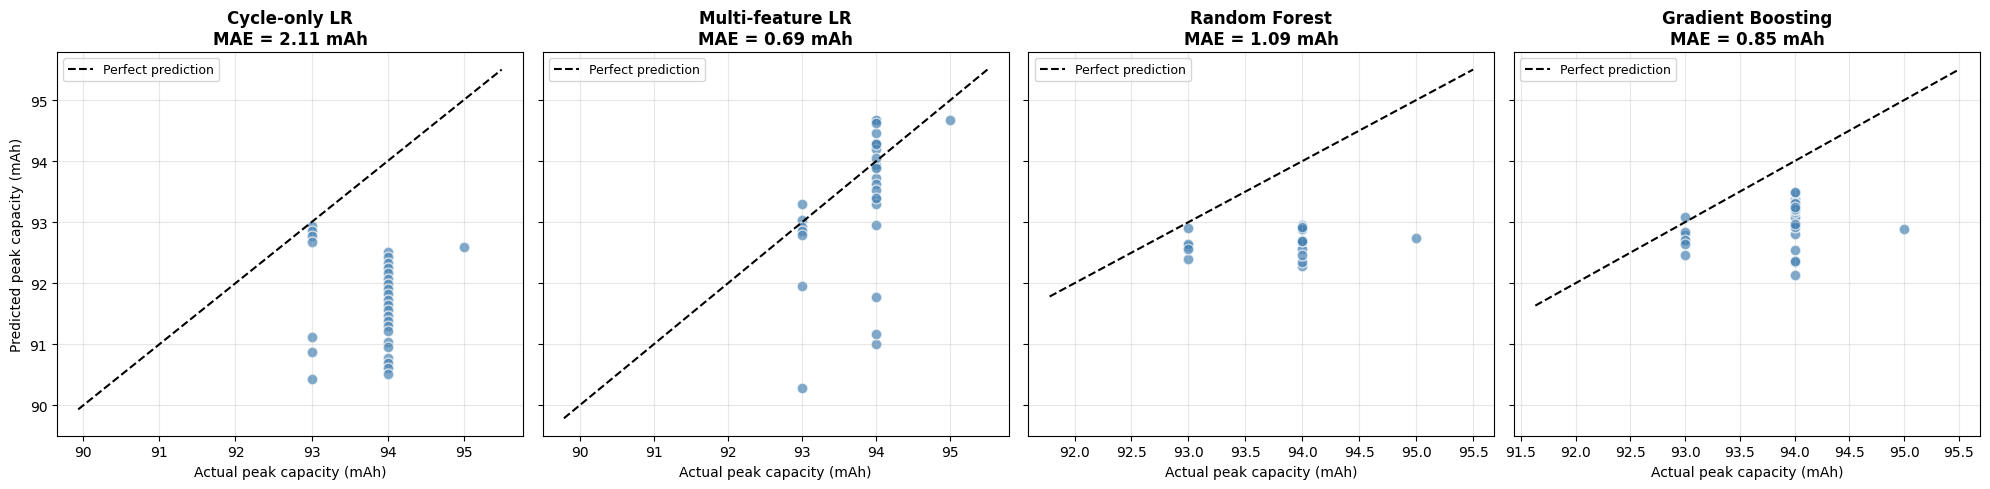

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, alpha=0.7, s=60, edgecolors='white', color='steelblue')
    lo, hi = min(y_test.min(), pred.min()) - 0.5, max(y_test.max(), pred.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect prediction')
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}\nMAE = {mae:.2f} mAh', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual peak capacity (mAh)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Predicted peak capacity (mAh)')
plt.tight_layout()
plt.show()


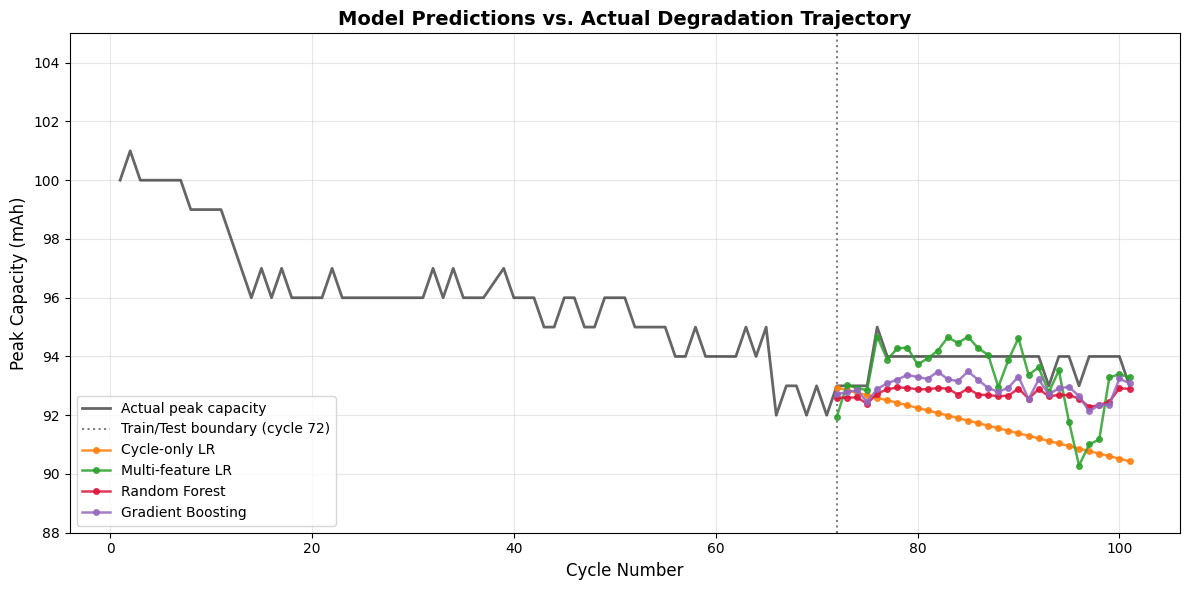

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_model['cycle_number'], df_model['peak_capacity'],
        color='black', linewidth=2, alpha=0.6, label='Actual peak capacity', zorder=2)

boundary = test['cycle_number'].iloc[0]
ax.axvline(boundary, color='gray', linestyle=':', linewidth=1.5,
           label=f'Train/Test boundary (cycle {boundary})')

colors = {'Cycle-only LR': 'tab:orange',
          'Multi-feature LR': 'tab:green',
          'Random Forest': 'crimson',
          'Gradient Boosting': 'tab:purple'}

for name, pred in predictions.items():
    ax.plot(test['cycle_number'], pred, marker='o', markersize=4,
            color=colors[name], linewidth=1.8, alpha=0.85, label=name)

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Peak Capacity (mAh)', fontsize=12)
ax.set_title('Model Predictions vs. Actual Degradation Trajectory',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim(88, 105)
plt.tight_layout()
plt.show()


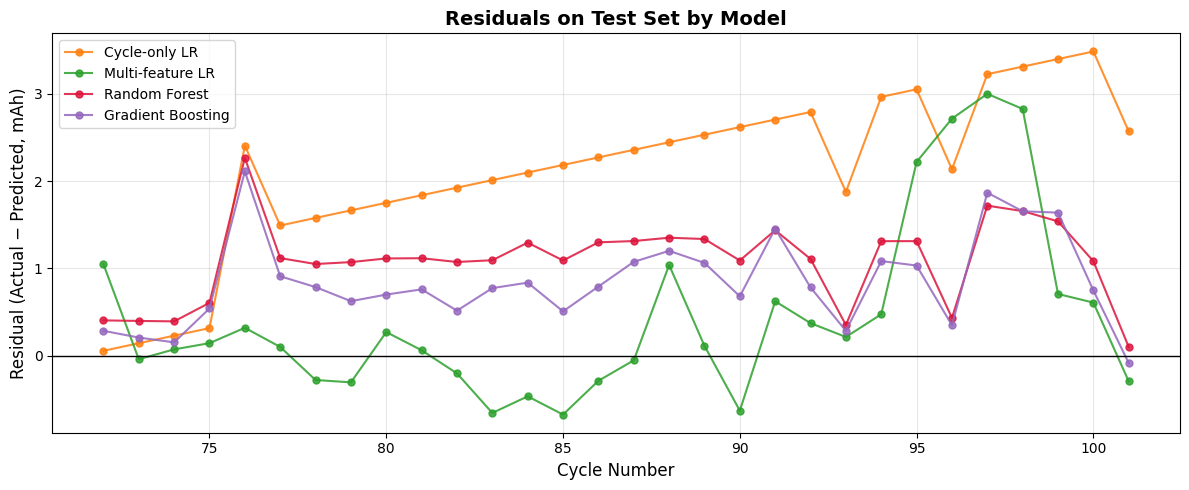

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, pred in predictions.items():
    residuals = y_test - pred
    ax.plot(test['cycle_number'], residuals, marker='o', markersize=5,
            linewidth=1.5, alpha=0.85, color=colors[name], label=name)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Residual (Actual − Predicted, mAh)', fontsize=12)
ax.set_title('Residuals on Test Set by Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Which Features Drive the Predictions?

Tree-based models expose feature-importance scores, which quantify how much each feature reduces prediction error across all the splits in the ensemble. Comparing the rankings of Random Forest and Gradient Boosting tells us whether the two models agree on what matters — agreement reinforces that the model has learned a stable representation rather than overfitting to noise.

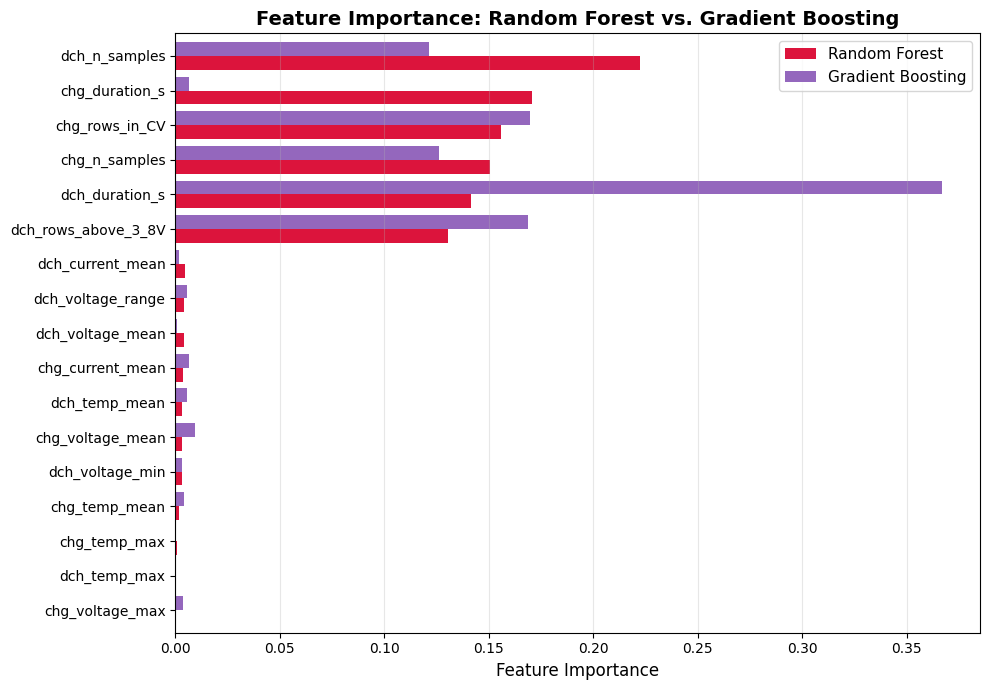


Feature importance table:
                     Random Forest  Gradient Boosting
dch_n_samples                0.222              0.121
chg_duration_s               0.171              0.007
chg_rows_in_CV               0.156              0.170
chg_n_samples                0.151              0.126
dch_duration_s               0.141              0.367
dch_rows_above_3_8V          0.130              0.169
dch_current_mean             0.005              0.002
dch_voltage_range            0.004              0.005
dch_voltage_mean             0.004              0.001
chg_current_mean             0.003              0.007
dch_temp_mean                0.003              0.005
dch_voltage_min              0.003              0.003
chg_voltage_mean             0.003              0.010
chg_temp_mean                0.002              0.004
chg_temp_max                 0.001              0.000
chg_voltage_max              0.000              0.004
dch_temp_max                 0.000              0.000


In [28]:
rf_importances = pd.Series(models['Random Forest'][0].feature_importances_,
                            index=feature_cols, name='Random Forest')
gb_importances = pd.Series(models['Gradient Boosting'][0].feature_importances_,
                            index=feature_cols, name='Gradient Boosting')

importance_df = (pd.concat([rf_importances, gb_importances], axis=1)
                   .sort_values('Random Forest', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
importance_df.plot(kind='barh', ax=ax, color=['crimson', 'tab:purple'], width=0.8)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Feature Importance: Random Forest vs. Gradient Boosting',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nFeature importance table:")
print(importance_df.round(3).sort_values('Random Forest', ascending=False))


### Discussion of Results

The two-pronged evaluation tells a consistent story. On the chronological hold-out test, Gradient Boosting achieves an MAE of 0.85 mAh — under 1% of nominal capacity. The negative R² values reported on this split are an artifact of evaluating on the stabilized late-life regime, where capacity varies by less than 0.4 mAh; any model with absolute error above that variance is automatically penalized regardless of how good the predictions are in absolute terms.

Cross-validation across the full lifecycle gives the cleaner picture. **Random Forest emerges as the best model with an R² of 0.893 and a mean absolute error of 0.383 mAh — a nearly six-fold improvement over the naive baseline (2.257 mAh) that always predicts the training mean.** Gradient Boosting performs essentially identically at R² = 0.885 and MAE = 0.393 mAh.

The ladder of progressively richer models shows that each modeling decision pays off:

| Model | CV R² | CV MAE | vs. naive baseline |
|---|---|---|---|
| Naive (mean prediction) | — | 2.257 mAh | — |
| Cycle-only LR | 0.622 | 0.866 mAh | 2.6× better |
| Multi-feature LR | 0.753 | 0.597 mAh | 3.8× better |
| **Random Forest** | **0.893** | **0.383 mAh** | **5.9× better** |
| Gradient Boosting | 0.885 | 0.393 mAh | 5.7× better |

- Cycle index alone is a strong but coarse baseline — degradation really is mostly time-driven.
- Adding engineered behavioral features in a linear model raises R² to 0.753, confirming that charge and discharge behavior carries information not contained in cycle number alone.
- Switching to non-linear ensembles raises R² to ~0.89. The remaining 14 percentage-point gain comes from capturing the curved early-life stabilization that linear models cannot represent.

Feature importance reveals that both ensemble methods rely on the same six dominant features — all related to either cycle "size" (sample counts, durations) or "shape" (constant-voltage tail length, time on the high-voltage plateau). The remaining eleven features carry essentially no weight (importance < 0.01) because the test protocol fixes voltage cutoffs, current rates, and ambient temperature, leaving them with little cycle-to-cycle variation to exploit.

Random Forest and Gradient Boosting distribute importance differently across the six dominant features. Random Forest spreads weight across all six (each between 0.13 and 0.22), while Gradient Boosting concentrates 0.37 on `dch_duration_s` alone and almost ignores `chg_duration_s` (0.007). This is classic ensemble behavior under multicollinearity: the length-related features all measure roughly the same thing ("how long was this cycle"), so Random Forest's random feature sub-sampling forces diversification, while Gradient Boosting's greedy boosting picks the single strongest predictor and discards close substitutes.

In practical terms, an MAE of 0.38 mAh means the model can predict cycle capacity to within 0.4% of nominal — sufficient precision for real-world remaining-useful-life estimation, where the conventional end-of-life threshold of 80% State-of-Health translates to a capacity drop of 20 mAh. The model's typical error is well below what would change an end-of-life decision.

## Insights and Conclusions

This project began with a deceptively simple question: **can we predict how a lithium-ion battery degrades from the data we already collect during normal cycling?** Over the course of the analysis we showed that the answer is yes — and that the gain over a naive baseline is roughly six-fold. But the more interesting findings are the *patterns* that emerged along the way: how degradation is structured, which behavioral signatures track it, and what those signatures reveal about the underlying physics. This section synthesizes those findings, acknowledges the limits of what we can conclude from a single battery cell, and outlines the directions a serious follow-up study would take.

### Answers to Our Three Research Questions

**1. Does battery capacity decline systematically with cycle count?**

Yes, decisively. Linear regression yields a slope of −0.058 mAh per cycle with a p-value of 2.31 × 10⁻²⁹, and both Pearson (r = −0.85) and Spearman (r = −0.89) correlations independently confirm a strong monotonic decline. The Spearman result is particularly important because it makes no assumption about the *shape* of the relationship — only that it is monotonic. The fact that both tests agree rules out the possibility that the linear-regression result is an artifact of imposing a straight line on curved data.

**2. Is the capacity gap between early-life and late-life cycles statistically significant?**

Yes. A two-sample t-test comparing cycles 1–20 against cycles 80–100 returns t = 11.65 (p = 9.94 × 10⁻¹⁵). Early cycles average 98.30 mAh, late cycles average 93.86 mAh — a 4.5% drop. Equally interesting is the variance asymmetry: early-cycle SD is 1.75 mAh while late-cycle SD is only 0.35 mAh. The battery does not just get weaker; it also stabilizes at its degraded capacity, with cycle-to-cycle behavior becoming more reproducible as the cell ages.

**3. Can per-cycle behavioral features predict capacity better than cycle index alone?**

Yes, by a wide margin. Cross-validated R² rises from 0.622 (cycle-index baseline) to 0.753 (multi-feature linear regression) to 0.893 (Random Forest). Mean absolute error drops correspondingly from 0.866 mAh to 0.383 mAh, a ~2.3× improvement over the cycle-only baseline. The features that drive this gain are physically interpretable — constant-voltage tail length, time on the high-voltage discharge plateau, and cycle duration — confirming that the model has learned a representation grounded in real electrochemistry rather than pattern-matching to noise.

### What These Results Show About Battery Health

These results reveal a few clear and important patterns about how lithium-ion batteries degrade over time.

**1. Battery aging is mostly driven by usage, but not only by cycle count.**  
The number of charge cycles alone explains most of the change in battery capacity (about 62%). This means that just knowing how many times a battery has been charged and discharged already gives a strong idea of its health. However, this is not the full picture. The extra improvement from engineered features shows that other factors—like charging behavior, temperature changes, and short-term fluctuations inside the battery—also matter. These details help make predictions more accurate, especially for estimating when a battery will reach the end of its useful life.

**2. The constant-voltage (CV) charging phase is very informative.**  
One of the strongest signals of battery health is how long the battery spends in the final part of charging, known as the constant-voltage stage (above 4.15 V). Healthy batteries spend more time in this stage because they can still accept charge efficiently. As batteries degrade, this time gets shorter. This happens because aging processes reduce the amount of usable lithium inside the battery. In simple terms: **a shorter CV phase usually means a more worn-out battery**. This makes it a very useful feature for tracking battery health in real time.

**3. Different models agree on what matters, but use it differently.**  
Both Random Forest and Gradient Boosting models identified the same key features as important, which is a strong sign that the findings are reliable. The difference is in how they use them. Random Forest treats all important features more evenly, while Gradient Boosting tends to focus more heavily on one or two strongest signals. This is just a difference in how the models are built, not a disagreement in the results. The key takeaway is that both methods point to the same core factors influencing battery health.

---

### Closing Summary

In simple terms, battery health is predictable and measurable using data that is already collected during normal operation. While cycle count explains most of the story, the most powerful indicators come from subtle charging behaviors—especially how the battery behaves in the final stage of charging. These signals make it possible to estimate battery degradation more accurately and understand how lithium-ion batteries wear out over time.


### References

- **CALCE Battery Data:** [https://calce.umd.edu/battery-data](https://calce.umd.edu/battery-data) — source dataset for this analysis.
- **scikit-learn documentation:** [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/) — reference for `LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`, `KFold`, `cross_val_score`, and the regression metrics used here.
- **scipy.stats:** [https://docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html) — reference for `pearsonr`, `spearmanr`, `linregress`, `ttest_ind`, and `mannwhitneyu`.
- Vetter, J. et al. (2005). "Ageing mechanisms in lithium-ion batteries." *Journal of Power Sources* 147(1–2): 269–281 — classic review of SEI growth and other capacity-fade mechanisms.
